<a href="https://colab.research.google.com/github/VieiraEduardo/analise_de_comportamento/blob/main/Analise_de_comportamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pipeline de Ciência de Dados


É importante definir todas as fases de criação de criação de um projeto que envolve Ciências de Dados, para detectar o problema de negócio e o objetivo desejado de forma eficiente.

1.Problema de Negócio

Os clientes que recebem desconto ou utilizam código promocional realmente gastam mais em média do que aqueles que não recebem?

👉 Objetivo: Avaliar se os investimentos em descontos e promoções estão aumentando o faturamento ou apenas reduzindo a margem de lucro.


Quais são os perfis de clientes mais valiosos (idade, gênero, frequência de compras, assinatura ativa) em termos de gasto médio total?

👉 Objetivo: Ajudar a empresa a focar em campanhas de marketing e fidelização nos segmentos que realmente geram mais receita.


Existe diferença significativa no valor médio das compras e satisfação (review rating) entre clientes que utilizam diferentes tipos de entrega (Express, Free Shipping, Next Day Air)?

👉 Objetivo: Avaliar se o tipo de frete impacta o gasto e a satisfação, ajudando na decisão de investir em logística premium ou otimizar custos.


2.Coleta e armasentamento de dados



3.Pré Processamento e limpeza dos dados

4.Analise Exploratória dos Dados

5.Modelagem

6.Avaliação de Modelo

7.Interpretação e comunicação dos resultados

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "shopping_behavior_updated.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "zubairamuti/shopping-behaviours-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipython-input-2352135327.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 407k/407k [00:00<00:00, 1.72MB/s]

First 5 records:    Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
df.sample(1)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3377,3378,37,Female,Shirt,Clothing,32,Kentucky,M,Yellow,Winter,4.6,No,Next Day Air,No,No,18,PayPal,Fortnightly


In [ ]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
# Dicionário para mapear os nomes das colunas em inglês para português
coluna_map = {
    'Age': 'Idade',
    'Gender': 'Gênero',
    'Item Purchased': 'Item Comprado',
    'Category': 'Categoria',
    'Purchase Amount (USD)': 'Valor da Compra (USD)',
    'Location': 'Localização',
    'Size': 'Tamanho',
    'Color': 'Cor',
    'Season': 'Estação',
    'Review Rating': 'Avaliação da Crítica',
    'Subscription Status': 'Status da Assinatura',
    'Shipping Type': 'Tipo de Frete',
    'Discount Applied': 'Desconto Aplicado',
    'Promo Code Used': 'Código Promocional Usado',
    'Previous Purchases': 'Compras Anteriores',
    'Payment Method': 'Método de Pagamento',
    'Frequency of Purchases': 'Frequência de Compras'
}

# Renomear as colunas do DataFrame
df.rename(columns=coluna_map, inplace=True)

# Exibir as primeiras linhas do DataFrame com os nomes das colunas traduzidas
display(df.head())

,Customer ID,Idade,Gênero,Item Comprado,Categoria,Valor da Compra (USD),Localização,Tamanho,Cor,Estação,Avaliação da Crítica,Status da Assinatura,Tipo de Frete,Desconto Aplicado,Código Promocional Usado,Compras Anteriores,Método de Pagamento,Frequência de Compras
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
# Exibir os nomes das colunas do DataFrame
print(df.columns)

Index(['Customer ID', 'Idade', 'Gênero', 'Item Comprado', 'Categoria',
       'Valor da Compra (USD)', 'Localização', 'Tamanho', 'Cor', 'Estação',
       'Avaliação da Crítica', 'Status da Assinatura', 'Tipo de Frete',
       'Desconto Aplicado', 'Código Promocional Usado', 'Compras Anteriores',
       'Método de Pagamento', 'Frequência de Compras'],
      dtype='object')


In [ ]:
# Select object type columns
object_columns = df.select_dtypes(include='object').columns

# Print unique values for each object column
for column in object_columns:
    print(f"Unique values for '{column}':")
    print(df[column].unique())
    print("-" * 30)

Unique values for 'Gênero':
['Male' 'Female']
------------------------------
Unique values for 'Item Comprado':
['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']
------------------------------
Unique values for 'Categoria':
['Clothing' 'Footwear' 'Outerwear' 'Accessories']
------------------------------
Unique values for 'Localização':
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virgin

array([[<Axes: title={'center': 'Customer ID'}>,
        <Axes: title={'center': 'Idade'}>],
       [<Axes: title={'center': 'Valor da Compra (USD)'}>,
        <Axes: title={'center': 'Avaliação da Crítica'}>],
       [<Axes: title={'center': 'Compras Anteriores'}>, <Axes: >]],
      dtype=object)

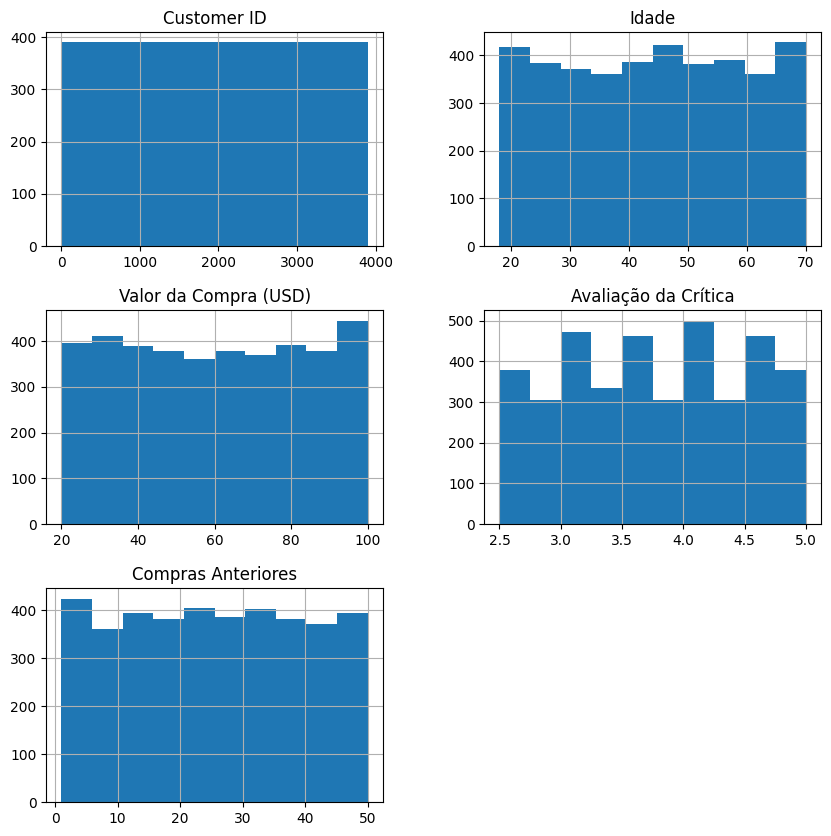

In [ ]:
# Verificar distribuição gaussiana dos dados
df.hist(figsize=(10, 10))

,0
Customer ID,"Axes(0.125,0.712609;0.168478x0.167391)"
Idade,"Axes(0.327174,0.712609;0.168478x0.167391)"
Valor da Compra (USD),"Axes(0.529348,0.712609;0.168478x0.167391)"
Avaliação da Crítica,"Axes(0.731522,0.712609;0.168478x0.167391)"
Compras Anteriores,"Axes(0.125,0.511739;0.168478x0.167391)"


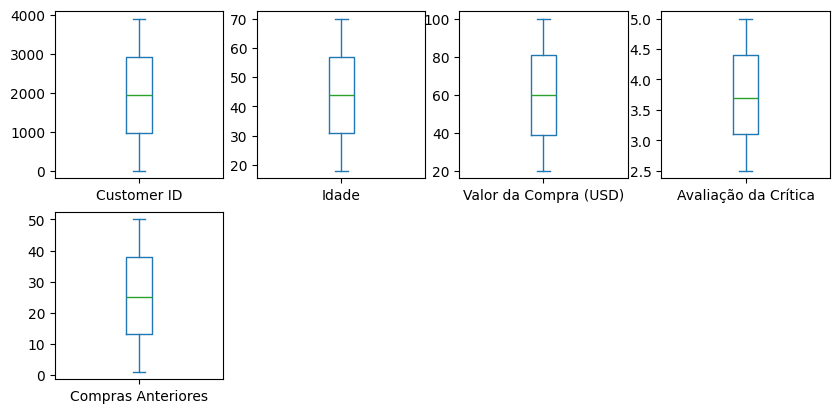

In [ ]:
# Verificar distribuição com o bloxplot
df.plot(kind='box', subplots=True, layout=(4, 4), figsize=(10, 10))

<Axes: xlabel='Gênero'>

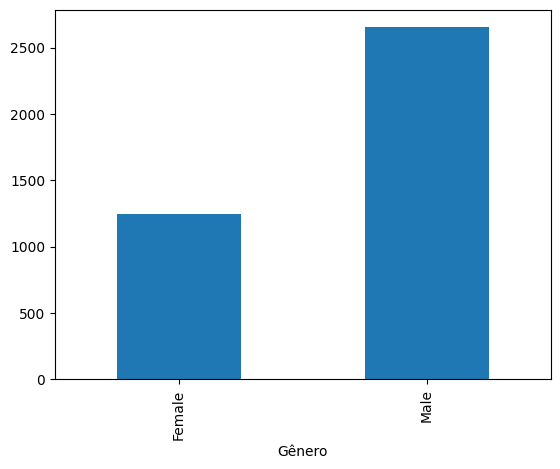

In [ ]:
# Comparar total de compras por genêro
df.groupby('Gênero')['Item Comprado'].count().plot(kind='bar')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Comparar gasto médio com e sem desconto
desconto = df.groupby("Desconto Aplicado")["Valor da Compra (USD)"].mean()

# Comparar gasto médio com e sem uso de promo code
promo = df.groupby("Código Promocional Usado")["Valor da Compra (USD)"].mean()

print("Gasto médio por desconto:\n", desconto, "\n")
print("Gasto médio por uso de promo code:\n", promo)



Gasto médio por desconto:
 Desconto Aplicado
No     60.130454
Yes    59.279070
Name: Valor da Compra (USD), dtype: float64 

Gasto médio por uso de promo code:
 Código Promocional Usado
No     60.130454
Yes    59.279070
Name: Valor da Compra (USD), dtype: float64


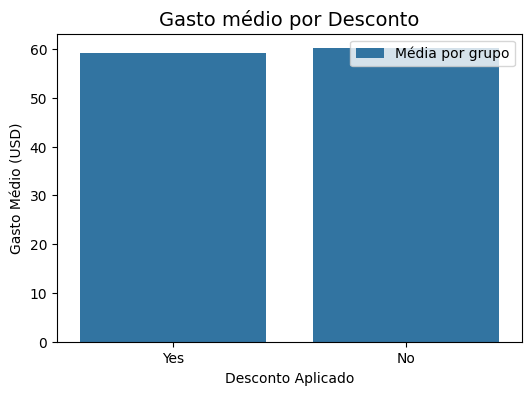

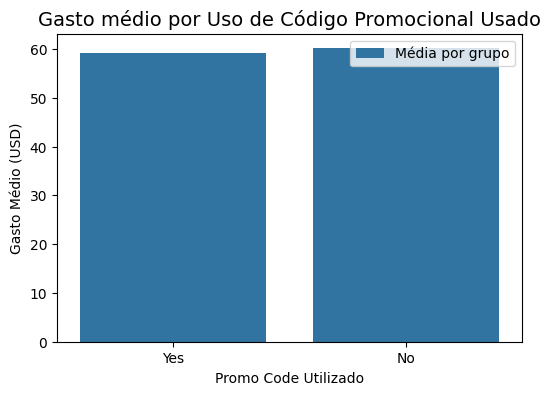

In [ ]:
# Plotar gráfico comparando
plt.figure(figsize=(6,4))
sns.barplot(x="Desconto Aplicado", y="Valor da Compra (USD)", data=df, estimator="mean", errorbar=None)
plt.title("Gasto médio por Desconto", fontsize=14)
plt.xlabel("Desconto Aplicado")
plt.ylabel("Gasto Médio (USD)")
plt.legend(["Média por grupo"])
plt.show()


# Protar gráfico comparando
plt.figure(figsize=(6,4))
sns.barplot(x="Código Promocional Usado", y="Valor da Compra (USD)", data=df, estimator="mean", errorbar=None)
plt.title("Gasto médio por Uso de Código Promocional Usado", fontsize=14)
plt.xlabel("Promo Code Utilizado")
plt.ylabel("Gasto Médio (USD)")
plt.legend(["Média por grupo"])
plt.show()



Os clientes que recebem desconto ou usam promo code gastam levemente menos (≈ $0,85 a menos por compra). Isso indica que a política de descontos não aumenta o ticket médio e pode estar apenas reduzindo a margem de lucro.

In [ ]:
# Agrupar por perfil (Idade, Gênero, Assinatura, Frequência)
segmentos = df.groupby(["Gênero", "Status da Assinatura", "Frequência de Compras"]) \
              .agg(
                  gasto_medio=("Valor da Compra (USD)", "mean"),
                  gasto_total=("Valor da Compra (USD)", "sum"),
                  qtd_clientes=("Customer ID", "nunique")
              ) \
              .reset_index() \
              .sort_values(by="gasto_total", ascending=False)

print("📊 Perfis de clientes mais valiosos:\n", segmentos.head(10))

📊 Perfis de clientes mais valiosos:
     Gênero Status da Assinatura Frequência de Compras  gasto_medio  \
12    Male                   No             Quarterly    58.141732   
9     Male                   No        Every 3 Months    58.073770   
7     Male                   No              Annually    61.105727   
10    Male                   No           Fortnightly    59.880531   
8     Male                   No             Bi-Weekly    61.716895   
11    Male                   No               Monthly    58.972603   
13    Male                   No                Weekly    59.390476   
2   Female                   No        Every 3 Months    62.161290   
1   Female                   No             Bi-Weekly    59.914894   
0   Female                   No              Annually    60.194595   

    gasto_total  qtd_clientes  
12        14768           254  
9         14170           244  
7         13871           227  
10        13533           226  
8         13516           219  


Os clientes homens, sem assinatura ativa, e com compras de média/baixa frequência (Quarterly e Every 3 Months) são os que mais geram receita total.
Ou seja, não são clientes super frequentes, mas quando compram gastam valores relevantes. Isso indica oportunidade de fidelização via assinatura para esse grupo.

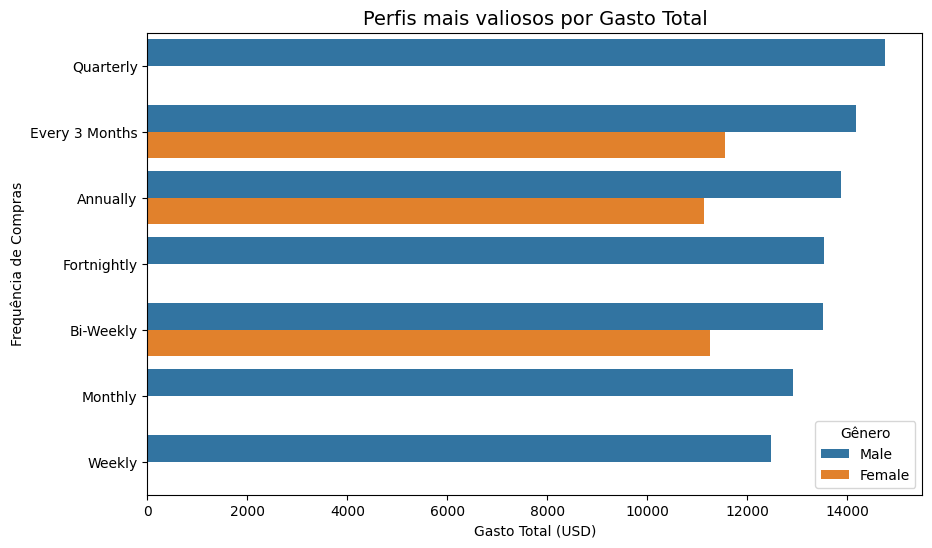

In [ ]:
# Plotar grafico por perfil(idade, gênero, Assinatura, Frequência)
# Top perfis por gasto total
segmentos = df.groupby(["Gênero", "Status da Assinatura", "Frequência de Compras"]) \
              .agg(gasto_total=("Valor da Compra (USD)", "sum")) \
              .reset_index() \
              .sort_values(by="gasto_total", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="gasto_total", y="Frequência de Compras", hue="Gênero", data=segmentos)
plt.title("Perfis mais valiosos por Gasto Total", fontsize=14)
plt.xlabel("Gasto Total (USD)")
plt.ylabel("Frequência de Compras")
plt.legend(title="Gênero")
plt.show()

In [ ]:
# Comparar valor médio de compra e avaliação por tipo de frete
logistica = df.groupby("Tipo de Frete").agg(
    gasto_medio=("Valor da Compra (USD)", "mean"),
    satisfacao_media=("Avaliação da Crítica", "mean"),
    total_clientes=("Customer ID", "nunique")
).reset_index()

print("Impacto do frete em gasto e satisfação:\n", logistica)

Impacto do frete em gasto e satisfação:
     Tipo de Frete  gasto_medio  satisfacao_media  total_clientes
0  2-Day Shipping    60.733652          3.761085             627
1         Express    60.475232          3.776935             646
2   Free Shipping    60.410370          3.717926             675
3    Next Day Air    58.631173          3.720833             648
4        Standard    58.460245          3.817737             654
5    Store Pickup    59.893846          3.706462             650


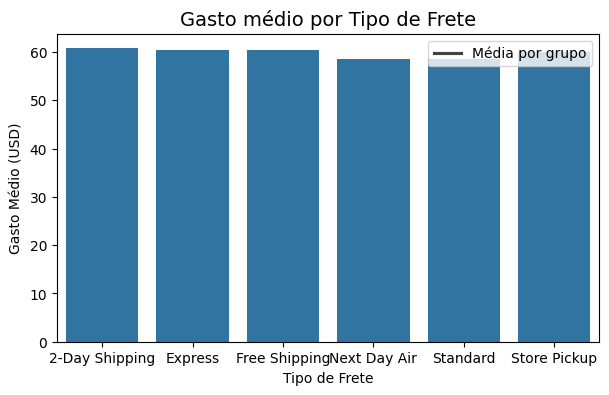

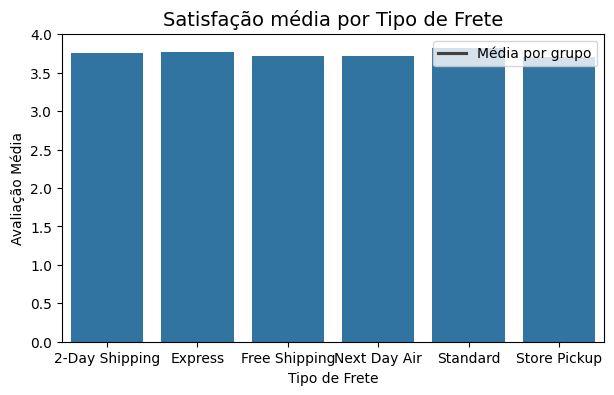

In [ ]:
plt.figure(figsize=(7,4))
sns.barplot(x="Tipo de Frete", y="gasto_medio", data=logistica)
plt.title("Gasto médio por Tipo de Frete", fontsize=14)
plt.xlabel("Tipo de Frete")
plt.ylabel("Gasto Médio (USD)")
plt.legend(["Média por grupo"])
plt.show()

# Gráfico 2: Satisfação média por tipo de frete
plt.figure(figsize=(7,4))
sns.barplot(x="Tipo de Frete", y="satisfacao_media", data=logistica)
plt.title("Satisfação média por Tipo de Frete", fontsize=14)
plt.xlabel("Tipo de Frete")
plt.ylabel("Avaliação Média")
plt.legend(["Média por grupo"])
plt.show()

Maior gasto médio: clientes que usam 2-Day Shipping ($60,73).

Maior satisfação: clientes que usam Standard Shipping (3,82/5).

Next Day Air (frete mais rápido) tem gasto médio mais baixo ($58,63) e satisfação igual a Free Shipping (3,72).

Ou seja, investir em logística premium (entregas mais caras e rápidas) não se traduz necessariamente em maior receita ou satisfação.


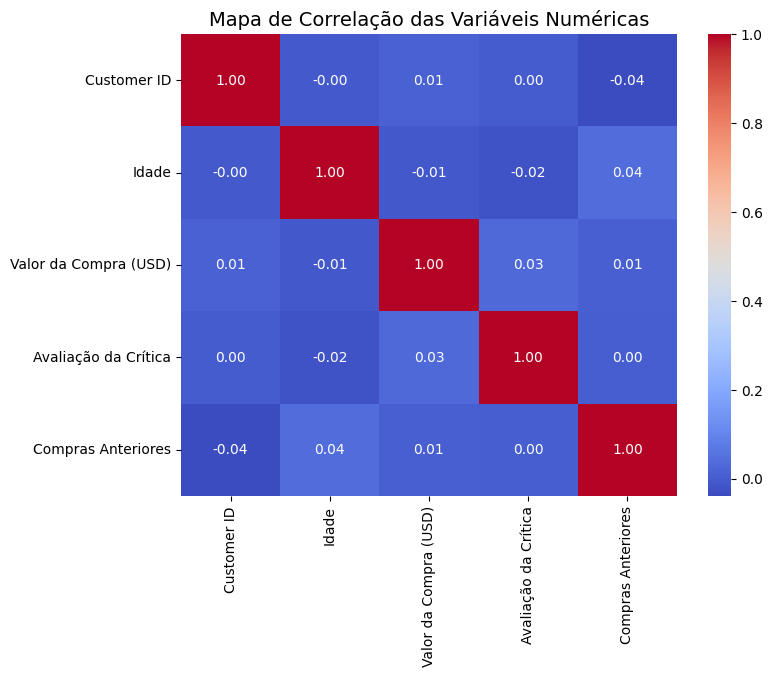

In [ ]:
# Selecionar apenas colunas numéricas para o mapa de correlação
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Criar mapa de correlação das variáveis numéricas
correlacao = df_numeric.corr()

# Plotar o mapa de calor da correlação
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Correlação das Variáveis Numéricas", fontsize=14)
plt.show()

## Modelo K-means para descobrir novas segmentações

In [ ]:
# Aqui escolhemos variáveis numéricas ligadas ao comportamento de compra
features = df[["Idade", "Valor da Compra (USD)", "Compras Anteriores", "Avaliação da Crítica"]]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# Normalizar os dados
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

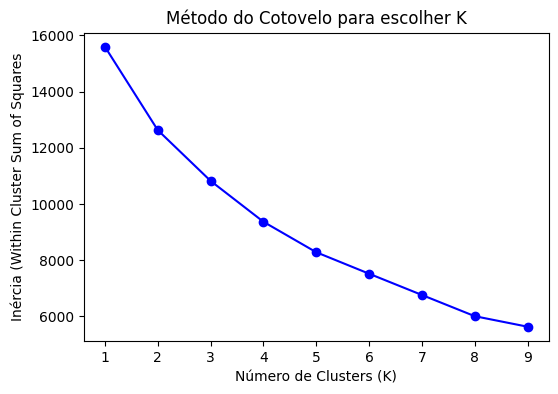

In [ ]:
# Escolher número ideal de clusters
inertia = []
K = range(1, 10)
for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Adicionado n_init para evitar warning
  kmeans.fit(scaled_features)
  inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'bo-') # Corrigido para usar K em vez de k
plt.xlabel('Número de Clusters (K)') # Corrigido o título
plt.ylabel('Inércia (Within Cluster Sum of Squares')
plt.title('Método do Cotovelo para escolher K')
plt.show() # Corrigido plt.show

# # Treinar modelo com k=4 (exemplo) - Comentado para que você escolha o K ideal do gráfico acima
# kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
# df["Cluster"] = kmeans.fit_predict(scaled_features)

# # Analisar os Clusters - Comentado para que você escolha o K ideal do gráfico acima
# clusters_sumary = df.groupby('Cluster').agg(
#     idade_media = ('Idade', 'mean'),
#     valor_medio = ('Valor da Compra (USD)', 'mean'),
#     compras_anteriores_media = ('Compras Anteriores', 'mean'),
#     avaliacao_media = ('Avaliação da Crítica', 'mean'),
#     qtd_clientes = ('Customer ID', 'nunique')
# ).reset_index()

# print(clusters_sumary)

# # Visualizar Clusters - Comentado para que você escolha o K ideal do gráfico acima
# plt.figure(figsize=(7,5))
# sns.scatterplot(x=df['Idade'], y=df['Valor da Compra (USD)'], hue=df['Cluster'], palette="Set2")
# plt.title('Segmentação de Clientes com K-Means')
# plt.xlabel('Idade')
# plt.ylabel('Valor da Compra USD')
# plt.legend(title='Cluster')
# plt.show()

In [ ]:
# o método cotovelo mostrou que 4 é o ideal
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # Adicionado n_init para evitar warning
df["Cluster"] = kmeans.fit_predict(scaled_features)

# Resumindo os clusters
cluster_summary = df.groupby("Cluster").agg(
    idade_media=("Idade", "mean"),
    gasto_medio=("Valor da Compra (USD)", "mean"),
    compras_anteriores=("Compras Anteriores", "mean"),
    avaliacao_media=("Avaliação da Crítica", "mean"),
    qtd_clientes=("Customer ID", "nunique")
).round(2)

print(cluster_summary)

         idade_media  gasto_medio  compras_anteriores  avaliacao_media  \
Cluster                                                                  
0              56.22        82.08               26.76             3.96   
1              31.33        54.86               24.98             4.43   
2              32.59        64.76               22.44             3.09   
3              56.26        37.57               27.26             3.54   

         qtd_clientes  
Cluster                
0                 966  
1                 969  
2                 986  
3                 979  


/tmp/ipython-input-293851065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='viridis')


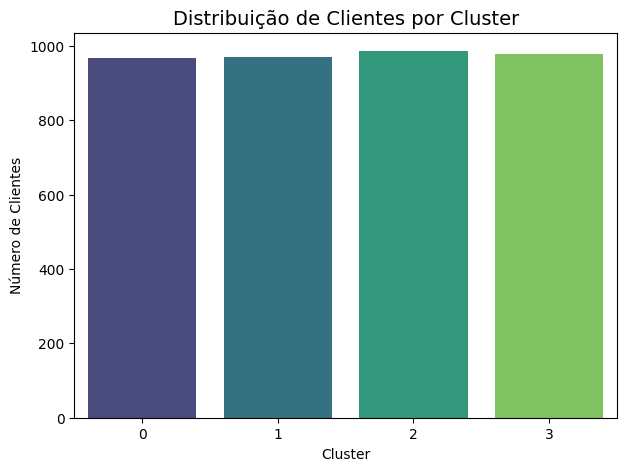

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='Cluster', data=df, palette='viridis')
plt.title('Distribuição de Clientes por Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Número de Clientes')
plt.show()

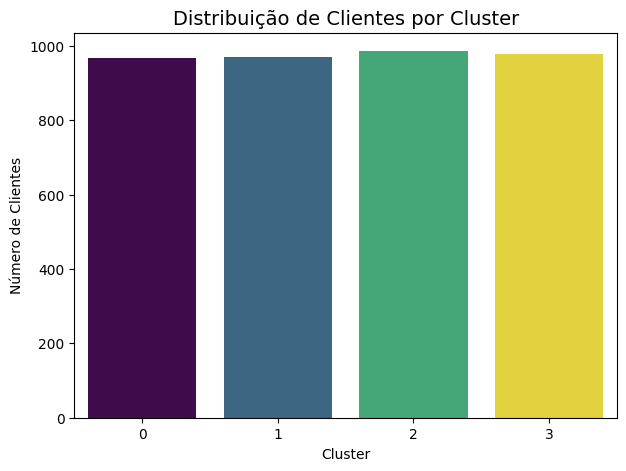

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='Cluster', data=df, palette='viridis', hue='Cluster', legend=False)
plt.title('Distribuição de Clientes por Cluster', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Número de Clientes')
plt.show()

/tmp/ipython-input-303912027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=column, data=cluster_summary, palette='viridis')


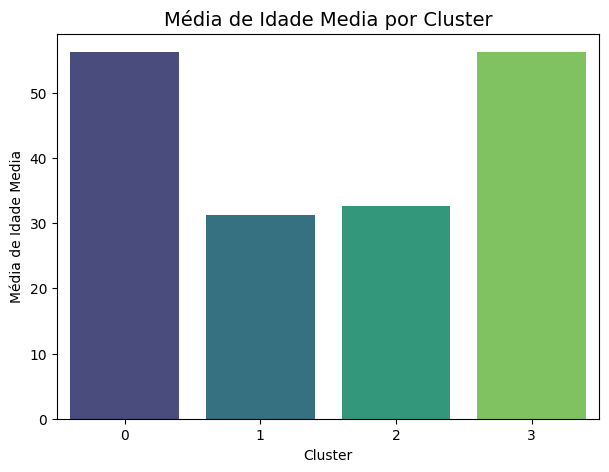

/tmp/ipython-input-303912027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=column, data=cluster_summary, palette='viridis')


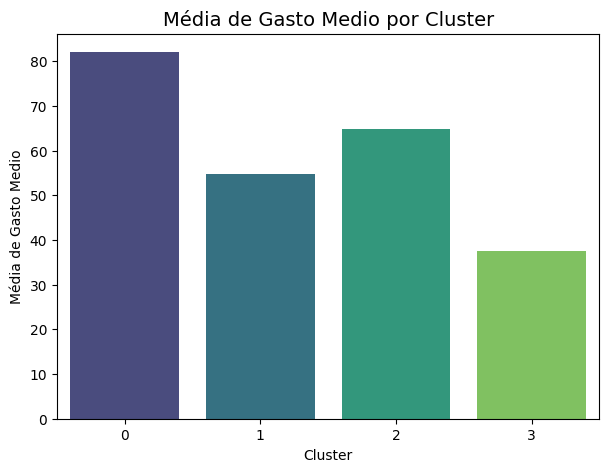

/tmp/ipython-input-303912027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=column, data=cluster_summary, palette='viridis')


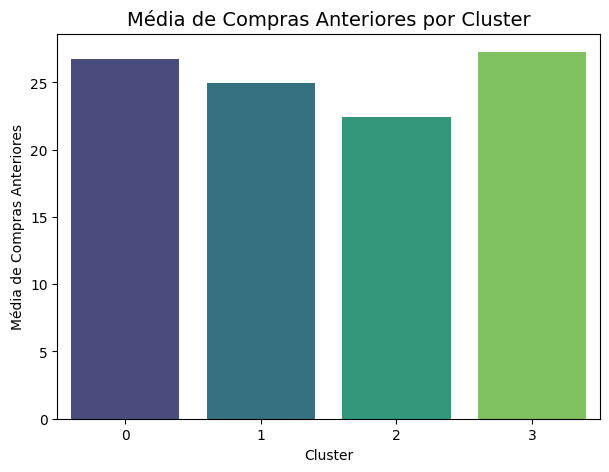

/tmp/ipython-input-303912027.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=column, data=cluster_summary, palette='viridis')


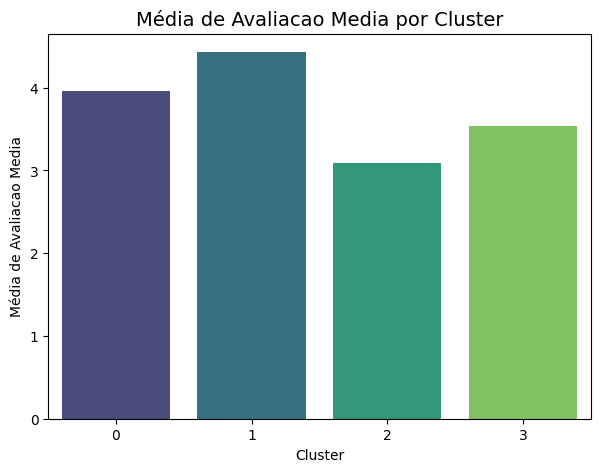

In [ ]:
for column in ['idade_media', 'gasto_medio', 'compras_anteriores', 'avaliacao_media']:
    plt.figure(figsize=(7, 5))
    sns.barplot(x=cluster_summary.index, y=column, data=cluster_summary, palette='viridis')
    plt.title(f'Média de {column.replace("_", " ").title()} por Cluster', fontsize=14)
    plt.xlabel('Cluster')
    plt.ylabel(f'Média de {column.replace("_", " ").title()}')
    plt.show()


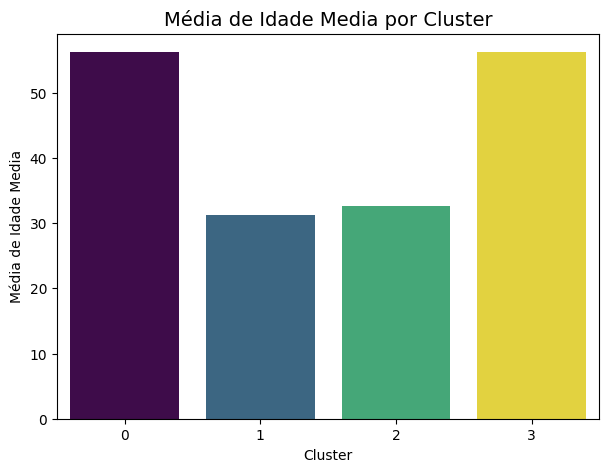

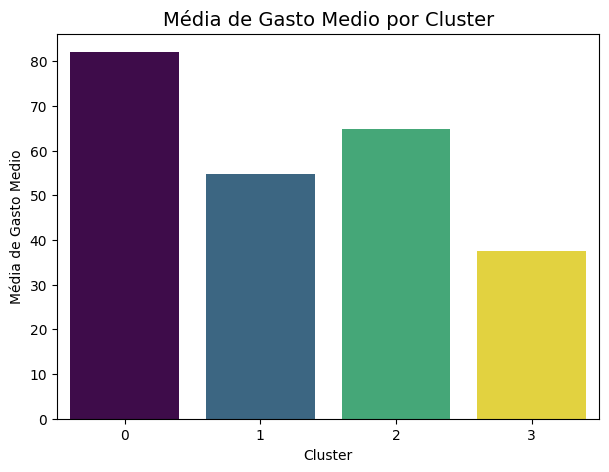

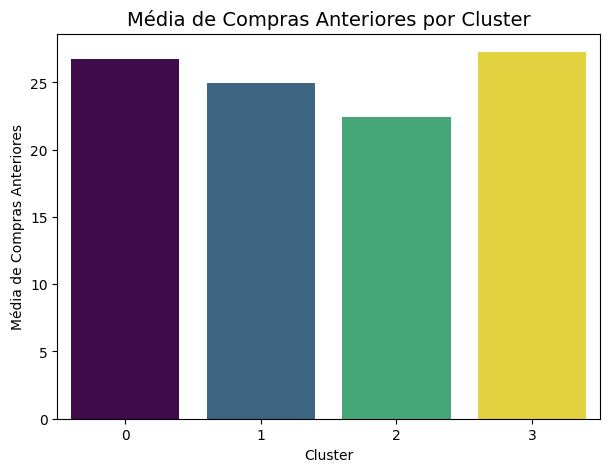

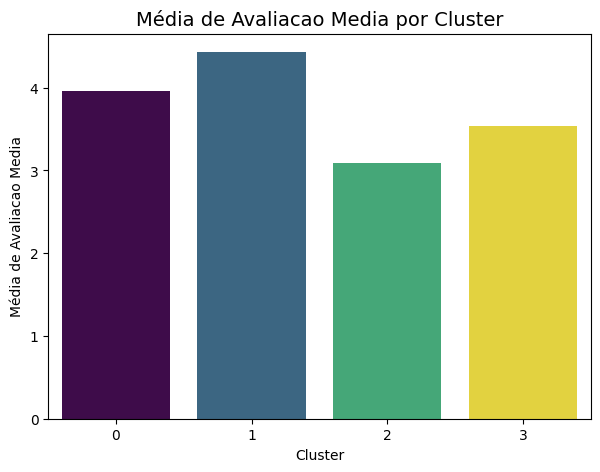

In [ ]:
for column in ['idade_media', 'gasto_medio', 'compras_anteriores', 'avaliacao_media']:
    plt.figure(figsize=(7, 5))
    sns.barplot(x=cluster_summary.index, y=column, data=cluster_summary, palette='viridis', hue=cluster_summary.index, legend=False)
    plt.title(f'Média de {column.replace("_", " ").title()} por Cluster', fontsize=14)
    plt.xlabel('Cluster')
    plt.ylabel(f'Média de {column.replace("_", " ").title()}')
    plt.show()

**Reasoning**:
Now that the mean characteristics of each cluster have been visualized, I will create a scatter plot to visualize the clusters using 'Idade' (Age) and 'Valor da Compra (USD)' (Purchase Amount) as axes, and color-code the points by 'Cluster' to show their distribution.



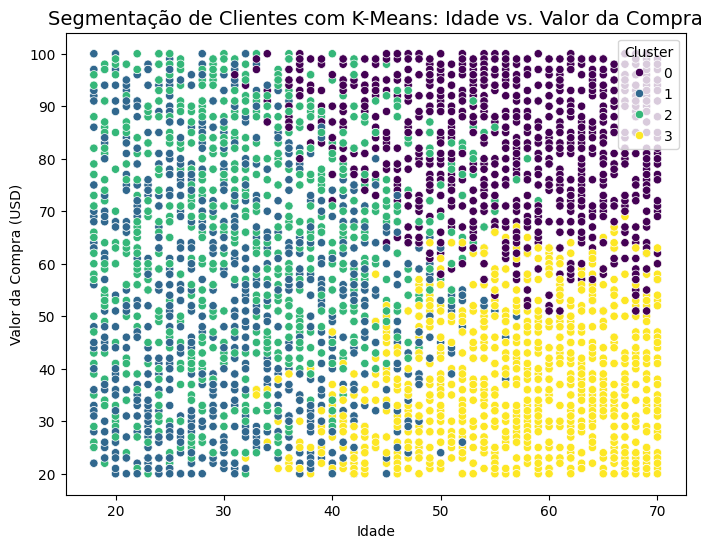

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Idade'], y=df['Valor da Compra (USD)'], hue=df['Cluster'], palette="viridis")
plt.title('Segmentação de Clientes com K-Means: Idade vs. Valor da Compra', fontsize=14)
plt.xlabel('Idade')
plt.ylabel('Valor da Compra (USD)')
plt.legend(title='Cluster')
plt.show()

### Análise Descritiva dos Clusters

Com base na `cluster_summary` e nos gráficos gerados, podemos descrever os perfis de cada cluster da seguinte forma:

**Cluster 0:**
*   **Idade Média:** 56.22 anos (mais velhos)
*   **Gasto Médio:** 82.08 USD (o maior gasto médio)
*   **Compras Anteriores:** 26.76 (alto número de compras anteriores)
*   **Avaliação Média:** 3.96 (satisfação moderadamente alta)
*   **Observação:** Este cluster representa clientes maduros, com alto poder de compra e que já possuem um histórico considerável de compras. São clientes valiosos com boa satisfação, indicando potencial para programas de fidelidade premium ou ofertas exclusivas para manter e aumentar o valor de vida do cliente.

**Cluster 1:**
*   **Idade Média:** 31.33 anos (mais jovens)
*   **Gasto Médio:** 54.86 USD (gasto médio)
*   **Compras Anteriores:** 24.98 (histórico de compras bom)
*   **Avaliação Média:** 4.43 (a mais alta satisfação)
*   **Observação:** Este cluster é composto por clientes jovens, com gasto médio e um bom volume de compras anteriores. O destaque é a alta satisfação. Estes podem ser clientes em potencial para crescimento, talvez com foco em ofertas para aumentar o ticket médio ou engajamento social da marca.

**Cluster 2:**
*   **Idade Média:** 32.59 anos (jovens/adultos jovens)
*   **Gasto Médio:** 64.76 USD (gasto médio-alto)
*   **Compras Anteriores:** 22.44 (histórico de compras moderado)
*   **Avaliação Média:** 3.09 (a mais baixa satisfação)
*   **Observação:** Este cluster tem clientes jovens com gasto médio-alto, mas a mais baixa avaliação de crítica. Representa um grupo com alto risco de churn ou insatisfação. Campanhas de follow-up pós-compra, pesquisa de satisfação aprofundada e resolução proativa de problemas seriam cruciais para este segmento.

**Cluster 3:**
*   **Idade Média:** 56.26 anos (mais velhos)
*   **Gasto Médio:** 37.57 USD (o menor gasto médio)
*   **Compras Anteriores:** 27.26 (alto número de compras anteriores)
*   **Avaliação Média:** 3.54 (satisfação moderada)
*   **Observação:** Clientes maduros com o menor gasto médio, mas um histórico robusto de compras anteriores. Isso pode indicar que eles compram itens de menor valor ou que são sensíveis a preço. Estratégias de up-selling/cross-selling de produtos complementares ou de maior valor agregado, bem como promoções personalizadas, podem ser eficazes.

### Conclusão e Insights Gerais

A segmentação por K-Means revelou perfis distintos de clientes, o que pode guiar estratégias de marketing e vendas mais eficazes:

*   **Oportunidade de Valor:** O **Cluster 0** (clientes mais velhos, de alto gasto e boas avaliações) são os mais valiosos e devem ser focados em retenção e valor de vida do cliente. O **Cluster 1** (jovens e com alta satisfação) são promissores para crescimento.
*   **Pontos de Atenção:** O **Cluster 2** (jovens e insatisfeitos) requer intervenção urgente para melhorar a satisfação e evitar perda de clientes. O **Cluster 3** (mais velhos, mas de baixo gasto) pode ser incentivado a aumentar o valor médio das compras.
*   **Personalização:** As campanhas de marketing devem ser personalizadas para cada cluster. Por exemplo, ofertas de produtos premium para o Cluster 0, programas de indicação para o Cluster 1, suporte ao cliente aprimorado para o Cluster 2 e promoções de valor para o Cluster 3.

Esta análise demonstra que o valor do cliente não se limita apenas ao gasto, mas também à sua idade, histórico de compras e satisfação.

## Finalizando a Análise e Visualização dos Clusters



## Resumo:

### Perguntas e Respostas
A análise identificou quatro clusters de clientes distintos, cada um com características únicas relacionadas à idade, valor de compra, compras anteriores e classificação de avaliação. Esses insights podem ser aproveitados para campanhas de marketing direcionadas e estratégias de negócios:
*   **Cluster 0 (Mais Velhos, Altos Gastadores, Boa Satisfação):** Esses clientes valiosos devem ser o foco de programas de fidelidade premium e ofertas exclusivas para garantir a retenção e aumentar o valor vitalício do cliente.
*   **Cluster 1 (Mais Jovens, Gastadores Médios, Maior Satisfação):** Como um grupo promissor para o crescimento, as estratégias devem se concentrar em aumentar o valor médio da transação (por exemplo, upselling) e aproveitar sua alta satisfação para a promoção da marca por meio de engajamento social ou programas de indicação.
*   **Cluster 2 (Jovens/Adultos Jovens, Gastadores Médio-Altos, Menor Satisfação):** Este cluster apresenta um alto risco de rotatividade. A intervenção urgente por meio de acompanhamentos pós-compra aprimorados, pesquisas aprofundadas de satisfação e resolução proativa de problemas é crucial para melhorar sua experiência.
*   **Cluster 3 (Mais Velhos, Baixos Gastadores, Satisfação Moderada):** Apesar de um histórico de compras robusto, seus gastos médios baixos sugerem sensibilidade ao preço ou preferência por itens de menor valor. Estratégias como promoções personalizadas, up-selling e cross-selling de produtos complementares ou de maior valor agregado podem ser eficazes.

### Principais Descobertas da Análise de Dados
*   A base de clientes foi segmentada com sucesso em quatro clusters distintos usando K-Means.
*   O **Cluster 0** compreende clientes mais velhos (idade média de 56,22 anos) com o maior gasto médio (US$ 82,08) e um histórico de compras significativo (26,76 compras anteriores), mostrando satisfação moderadamente alta (classificação média de avaliação de 3,96).
*   O **Cluster 1** representa clientes mais jovens (idade média de 31,33 anos) com um bom histórico de compras (24,98 compras anteriores) e a maior satisfação (classificação média de avaliação de 4,43), apesar de um gasto médio moderado (US$ 54,86).
*   O **Cluster 2** consiste em jovens adultos (idade média de 32,59 anos) que gastam moderadamente alto (US$ 64,76), mas exibem a menor satisfação média (classificação média de avaliação de 3,09).
*   O **Cluster 3** identifica clientes mais velhos (idade média de 56,26 anos) com o menor gasto médio (US$ 37,57), mas um número substancial de compras anteriores (27,26), juntamente com satisfação moderada (classificação média de avaliação de 3,54).
*   As visualizações, incluindo gráficos de contagem para distribuição de clusters, gráficos de barras para características médias e um gráfico de dispersão de 'Idade' vs. 'Valor da Compra (USD)' colorido por cluster, ilustraram com sucesso os perfis distintos e a separação desses segmentos.

### Insights ou Próximos Passos
*   **Priorizar a Retenção e o Crescimento do Cliente:** Concentrar-se no Cluster 0 (mais valioso) e no Cluster 1 (alta satisfação, potencial de crescimento) com programas de fidelidade e estratégias de engajamento personalizados.
*   **Abordar a Insatisfação do Cliente de Forma Proativa:** Implementar ações imediatas para o Cluster 2, que mostra a menor satisfação, para mitigar o risco de rotatividade por meio de suporte direcionado e mecanismos de feedback.